# Evaluate — how well did the clones learn?

Two questions:

1. **Imitation accuracy** — on a *held-out world*, how closely does each network reproduce
   the teacher's action? (heading cosine + per-channel classification accuracy)
2. **Behaviour in the wild** — dropped into the full `Simulation` on an **unseen** world, does
   the learned brain keep sheep and foxes alive with dynamics resembling the RuleBrain's?

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
for _c in (_cwd, _cwd / "notebooks" / "imitation_learning"):
    if (_c / "common.py").exists():
        sys.path.insert(0, str(_c)); break
import numpy as np
import matplotlib.pyplot as plt
import torch
import common as C
from config import SHEEP, FOX, SPECIES_NAMES
from sim.brain import RuleBrain

device = "cuda" if torch.cuda.is_available() else "cpu"
models = {sid: C.load_model(sid, device=device) for sid in C.SPECIES_IDS}
print("loaded models:", {SPECIES_NAMES[s]: str(C.MODEL_PATHS[s].name) for s in C.SPECIES_IDS})

loaded models: {'sheep': 'sheep.pt', 'fox': 'fox.pt'}


## 1. Imitation accuracy on the held-out world

Each model was validated on the last world in the collection; we recompute its metrics on
exactly those rows (a map it never trained on).

Two heading numbers: `head_cos` averages over **all** rows, but the teacher steers by a
*random explore angle* whenever nothing is urgent (an unlearnable direction), which drags
that number down. `head_cos*` averages only over the rows where the clone **commits** to a
direction (`|pred|>0.3`, i.e. it is actually pursuing something perceived) — the honest
measure of whether it points the right way. `conf` is the fraction of rows that are.

In [2]:
rows = []
for sid in C.SPECIES_IDS:
    d = C.load_dataset(sid)
    val_world = int(d['world'].max())
    m = models[sid]
    _, val_idx = C.split_by_world(d, val_world)
    g = torch.from_numpy(d['grids'][val_idx]).to(device).float()
    s = torch.from_numpy(d['scalars'][val_idx]).to(device)
    a = torch.from_numpy(d['actions'][val_idx]).to(device)
    with torch.no_grad():
        met = C.bc_metrics(m(g, s), a)
    rows.append((SPECIES_NAMES[sid], len(val_idx), met))

print(f"{'species':>6} {'n_val':>7} {'head_cos':>9} {'head_cos*':>10} {'conf':>6} "
      f"{'eat':>6} {'drink':>6} {'repro':>6} {'speed':>6}")
for name, n, met in rows:
    print(f"{name:>6} {n:>7} {met['heading_cos']:>9.3f} {met['heading_cos_conf']:>10.3f} "
          f"{met['conf_frac']:>6.2f} {met['eat_acc']:>6.2f} "
          f"{met['drink_acc']:>6.2f} {met['repro_acc']:>6.2f} {met['speed_acc']:>6.2f}")
print("\nhead_cos* = cosine on rows where the clone commits (|pred|>0.3); "
      "1.0 = points exactly where the teacher did.")

species   n_val  head_cos  head_cos*   conf    eat  drink  repro  speed
 sheep    6000     0.371      0.439   0.73   0.64   0.70   0.81   0.85
   fox    3000     0.060      0.143   0.63   0.78   0.78   0.74   0.79

head_cos* = cosine on rows where the clone commits (|pred|>0.3); 1.0 = points exactly where the teacher did.


## 2. Behaviour in the full simulation (unseen world)

Drop each brain into the full `Simulation` on a world seed that was **not** in the training
set, and compare population curves. Three brains:

- **RuleBrain** — the teacher.
- **clone (greedy)** — the network's action taken as-is.
- **clone + explore** — the same network, but on ticks where it does *not* commit to a target
  (`|heading| < 0.3`) we substitute a random full-speed heading.

Why the third? The teacher is *stateless*, so its one unlearnable ingredient is that it
**explores by a fresh random heading** each tick — something a memoryless deterministic clone
can't reproduce (same view ⇒ same heading every tick). The explore variant supplies that
missing wander, isolating whether exploration is the bottleneck or whether the greedy clone
already covers enough ground on its own.

In [3]:
EVAL_WORLD = 424242     # not in WORLD_SEEDS
EVAL_SEED  = 7
TICKS      = 2000

brains = {
    "RuleBrain": lambda cfg: RuleBrain(np.random.default_rng(EVAL_SEED), cfg.sim.food_eat_threshold),
    "clone (greedy)": lambda cfg: C.LearnedPolicyBrain(models, device=device),
    "clone + explore": lambda cfg: C.LearnedPolicyBrain(models, device=device, explore_seed=EVAL_SEED),
}
hist = {}
for name, fn in brains.items():
    print(name)
    hist[name] = C.run_headless(fn, EVAL_WORLD, EVAL_SEED, TICKS)

RuleBrain


  t=  200  sheep= 296  fox=  22


  t=  400  sheep= 197  fox=  16


  t=  600  sheep= 147  fox=  15


  t=  800  sheep= 142  fox=  15


...

  t= 1200  sheep=  66  fox=   0


  t= 1400  sheep=  68  fox=   0


  t= 1600  sheep=  68  fox=   0


  t= 1800  sheep=  57  fox=   0


  t= 2000  sheep=  56  fox=   0


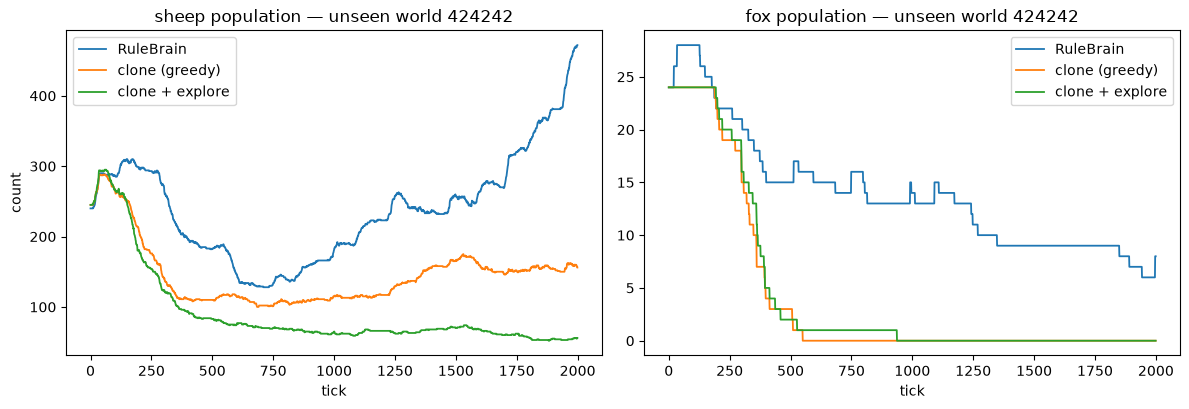

           brain    sheep (mean/final)    fox (mean/final)
       RuleBrain               323/472                 8/8
  clone (greedy)               156/156                 0/0
 clone + explore                 60/56                 0/0

(last-500-tick mean / final count)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for a, sp in zip(ax, ("sheep", "fox")):
    for name, h in hist.items():
        a.plot(h[sp], label=name, lw=1.3)
    a.set_title(f"{sp} population — unseen world {EVAL_WORLD}")
    a.set_xlabel("tick"); a.legend()
ax[0].set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"{'brain':>16}  {'sheep (mean/final)':>20}  {'fox (mean/final)':>18}")
for name, h in hist.items():
    sm = f"{int(np.mean(h['sheep'][-500:]))}/{h['sheep'][-1]}"
    fm = f"{int(np.mean(h['fox'][-500:]))}/{h['fox'][-1]}"
    print(f"{name:>16}  {sm:>20}  {fm:>18}")
print("\n(last-500-tick mean / final count)")

**Reading it (typical result).**

- **Sheep transfer well.** The greedy clone sustains a stable sheep population (roughly half
  the teacher's level) for the whole run on a map it never trained on — from perception alone,
  with no memory. Interestingly the greedy clone holds *better* than the explore variant here:
  the learned policy already moves purposefully enough that injected random wandering mostly
  pulls sheep off good ground. So exploration was **not** the bottleneck — class-balanced gate
  cloning (so the clone actually eats/drinks/breeds at the teacher's rate) was.
- **Foxes still die out.** Hunting needs a precise pursuit heading toward sparse, fast-moving
  prey, and that is exactly where the clone is weakest (`head_cos*` for the fox is low) — there
  is far less fox data and the signal is dominated by the teacher's unlearnable exploration.
  A memoryless single-step clone can't hold a predator together across prey troughs.

That fox gap is the point of the split: it is what the next stages are for — **add the LSTM
memory back** (so pursuit and persistence can use history, not just the current frame) and
**fine-tune with RL** on the reward/pain signal so the predator learns to survive, not just
to copy one step of the teacher.